In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# read the data
df = pd.read_csv(r"")
df

,customer_key,customer_number,customer_name,age,age_category,total_orders,total_sales,spender_category,last_order_date,recency,total_quantities,total_products,life_span,average_order_value,average_monthly_spend
0,1,AW00011001,Eugene Huang,49.0,40-60,3,6235,high spender,2013-12-10,147,3,3,147,2078.3333,42.4150
1,2,AW00011002,Ruben Torres,55.0,40-60,3,8079,high spender,2013-02-23,157,3,3,157,2693.0000,51.4586
2,3,AW00011003,Christy Zhu,52.0,40-60,3,8079,high spender,2013-05-10,154,3,3,154,2693.0000,52.4610
3,4,AW00011004,Elizabeth Johnson,46.0,40-60,3,8104,high spender,2013-05-01,154,3,3,154,2701.3333,52.6234
4,5,AW00011005,Julio Ruiz,49.0,40-60,3,8079,high spender,2013-05-02,154,3,3,154,2693.0000,52.4610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18474,18479,AW00029479,Tommy Tang,56.0,40-60,1,2049,medium spender,2012-09-04,162,1,1,162,2049.0000,12.6481
18475,18480,AW00029480,Nina Raji,48.0,40-60,1,2384,medium spender,2013-07-17,152,1,1,152,2384.0000,15.6842
18476,18481,AW00029481,Ivan Suri,60.0,40-60,1,3375,medium spender,2011-08-13,175,1,1,175,3375.0000,19.2857
18477,18482,AW00029482,Clayton Zhang,61.0,Above 60,1,2049,medium spender,2012-09-18,162,1,1,162,2049.0000,12.6481


In [3]:
df["total_sales"] =df["total_sales"].apply(lambda x: abs(x))

In [4]:
# analyze the data types and type of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18479 entries, 0 to 18478
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_key           18479 non-null  int64  
 1   customer_number        18479 non-null  object 
 2   customer_name          18479 non-null  object 
 3   age                    18463 non-null  float64
 4   age_category           18463 non-null  object 
 5   total_orders           18479 non-null  int64  
 6   total_sales            18479 non-null  int64  
 7   spender_category       18479 non-null  object 
 8   last_order_date        18479 non-null  object 
 9   recency                18479 non-null  int64  
 10  total_quantities       18479 non-null  int64  
 11  total_products         18479 non-null  int64  
 12  life_span              18479 non-null  int64  
 13  average_order_value    18479 non-null  float64
 14  average_monthly_spend  18479 non-null  float64
dtypes:

In [5]:
# classify the variables into facts and dimensions
df_columns = df.columns
df_num_columns = df.select_dtypes(include=['int', 'float']).columns.tolist()
df_num_columns

df_dim_columns = df_dim_columns = df.select_dtypes(include="object").columns.tolist()
df_dim_columns
print(f"The number of numeric column is: {len(df_num_columns)}")
print(f"The number of dimensional column is: {len(df_dim_columns)}")
print(f"The Totals of columns is: {len(df_columns)}")

The number of numeric column is: 10
The number of dimensional column is: 5
The Totals of columns is: 15


In [6]:
df_num_columns

['customer_key',
 'age',
 'total_orders',
 'total_sales',
 'recency',
 'total_quantities',
 'total_products',
 'life_span',
 'average_order_value',
 'average_monthly_spend']

In [7]:
df_dim_columns

['customer_number',
 'customer_name',
 'age_category',
 'spender_category',
 'last_order_date']

<h3> The insights that can be gotten from the columns above are 
Revenue and profitability Insights </h3>

<p>

1. Which age_category generates the highest total_sales?

 Insight: Identifies your primary revenue-driving demographic for targeted marketing spend.

2. What is the relationship between spender_category and average_order_value (AOV)?

Insight: Validates if your "High Spenders" are buying expensive items or simply buying frequently.

3. How does average_monthly_spend differ across various age_categories?

 Insight: Helps predict monthly cash flow and identifies which age groups have the highest "wallet share."

4. Are customers with a high total_products count also those with the highest total_sales?

Insight: Determines if your revenue comes from high-volume "bulk" buyers or high-value "luxury" buyers.

5.Which spender_category has the highest total_quantities per order?

 Insight: Identifies potential wholesale or "power users" who move the most inventory.

</p>

Text(0.5, 1.0, 'Age Category Composition')

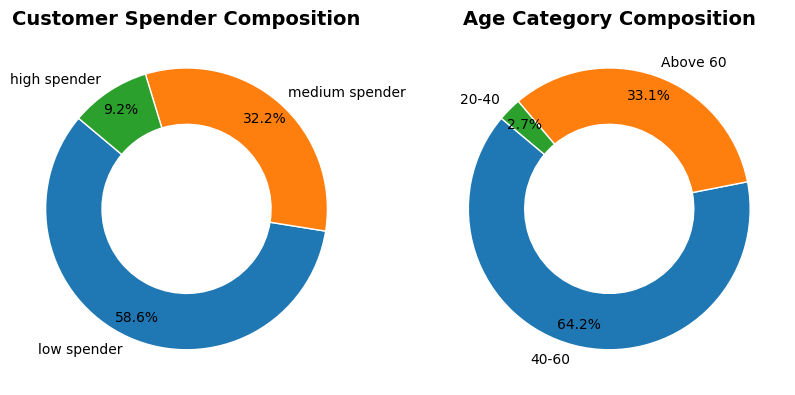

In [8]:
# proportion of a
fig, ax = plt.subplots(figsize=(10,10), nrows=1, ncols=2)
spender_counts = df["spender_category"].value_counts()
age_counts = df["age_category"].value_counts()
ax[0].pie(spender_counts, labels=spender_counts.index, autopct='%1.1f%%', 
               startangle=140, pctdistance=0.85, wedgeprops=dict(width=0.4, edgecolor='w'))
ax[0].set_title("Customer Spender Composition", fontsize=14, fontweight='bold')

ax[1].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', 
               startangle=140, pctdistance=0.85, wedgeprops=dict(width=0.4, edgecolor='w'))
ax[1].set_title("Age Category Composition", fontsize=14, fontweight='bold')

Text(0, 0.5, 'Age Category')

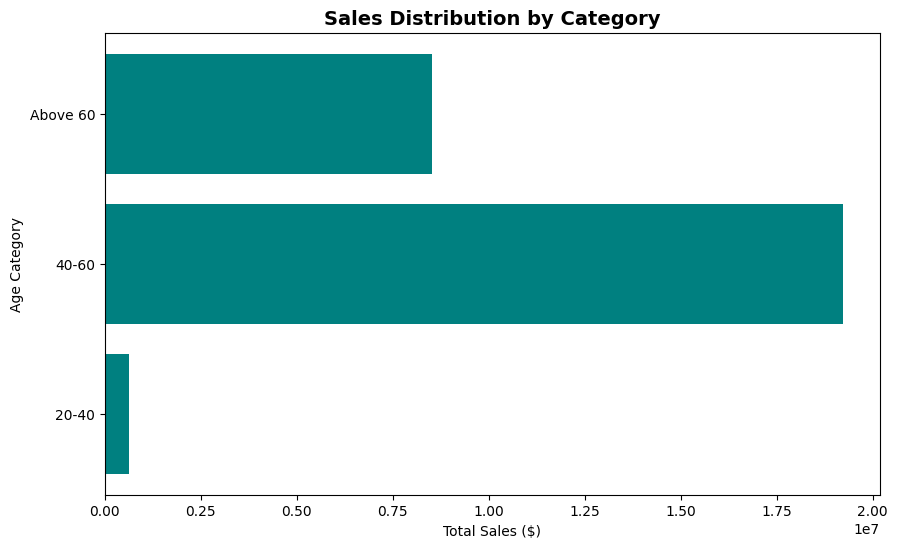

In [9]:
# 1. Age Category that generates the highest total_sales
fig, ax = plt.subplots(figsize=(10,6))
count_sales = df.groupby("age_category")["total_sales"].sum()
ax.barh(count_sales.index, count_sales.values, color="teal")
ax.set_title("Sales Distribution by Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Sales ($)")
ax.set_ylabel("Age Category")

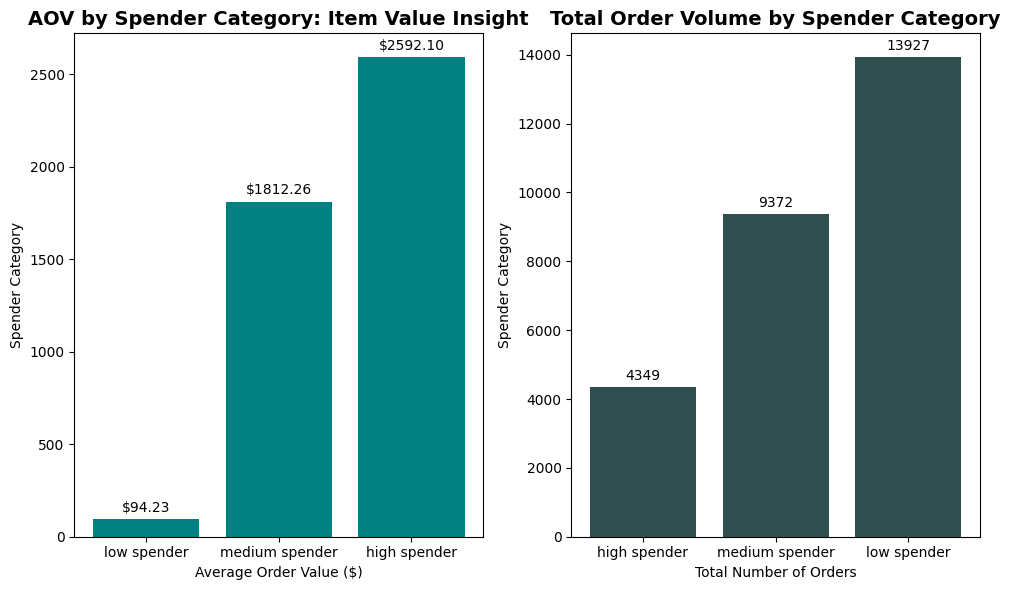

In [10]:
# 2. What is the relationship between spender_category and average_order_value (AOV)?

# Insight: Validates if your "High Spenders" are buying expensive items or simply buying frequently.
#  Setup the grid with 2 rows, 1 column
fig, ax = plt.subplots(figsize=(10, 6), nrows=1, ncols=2)

# PLOT 1: Average Order Value
spender_avg_aov = df.groupby("spender_category")["average_order_value"].mean().sort_values()
# Access the first axis using ax[0]
ax[0].bar(spender_avg_aov.index, spender_avg_aov.values, color="teal")
ax[0].set_title("AOV by Spender Category: Item Value Insight", fontsize=14, fontweight="bold")
ax[0].set_xlabel("Average Order Value ($)")
ax[0].set_ylabel("Spender Category")
ax[0].bar_label(ax[0].containers[0], fmt="$%.2f", padding=3)

# PLOT 2: Total Number of Orders 
spender_order_vol = df.groupby("spender_category")["total_orders"].sum().sort_values()
# Access the SECOND axis using ax[1]
ax[1].bar(spender_order_vol.index, spender_order_vol.values, color="darkslategray")
ax[1].set_title("Total Order Volume by Spender Category", fontsize=14, fontweight="bold")
ax[1].set_xlabel("Total Number of Orders")
ax[1].set_ylabel("Spender Category")
ax[1].bar_label(ax[1].containers[0], fmt="%d", padding=3)

# Final formatting to prevent overlapping
plt.tight_layout()
plt.show()



<p> Insight 2: High Spenders focus on premium transactions with an AOV ($2,592) nearly 28 times higher than Low Spenders, despite accounting for the smallest order volume (4,349). This inverse relationship confirms that High Spenders prioritize luxury/high-ticket services, whereas Low Spenders drive operational volume with nearly 14,000 low-value transactions.</p>

</br>

<p> 1. Low Spenders provide the Volume and brand awareness <p></br>2. Medium Spenders provide the Stability </br>3. High Spenders provide the Profit </br>

<h3>  I will recommend a moving of medium to high revenue base for example, if just 10% of your Medium Spenders is moved to the High Spender tier ($2,592), $780 extra is gained per transaction without spending a single kobo on new ads.</h3>

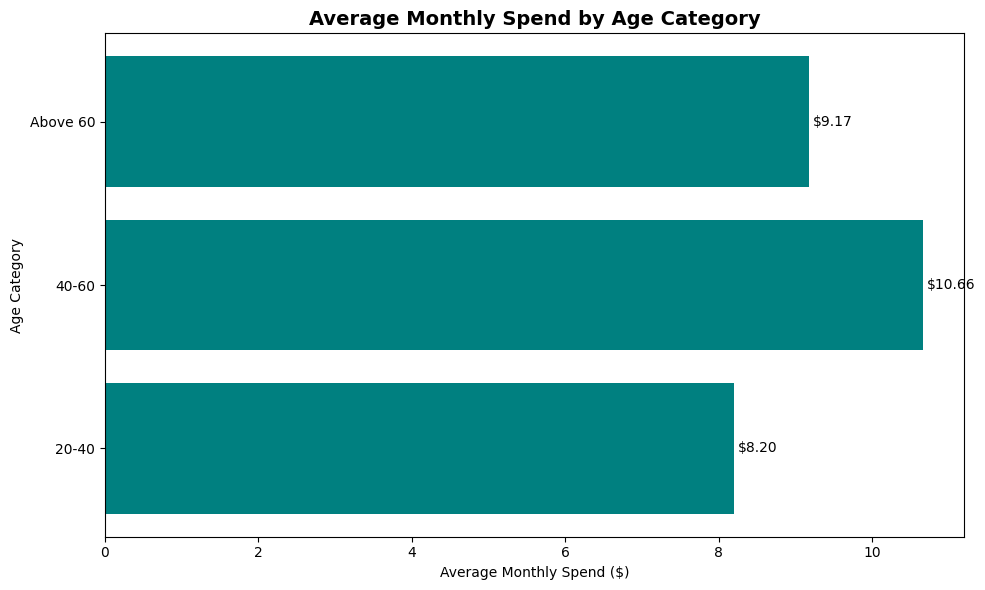

In [11]:
#3. How does average_monthly_spend differ across various age_categories?

# Insight: Helps predict monthly cash flow and identifies which age groups have the highest "wallet share."


# standardize the average monthly spend by finding the absolute of the negative values
df["average_monthly_spend"] = df["average_monthly_spend"].apply(lambda x: abs(x))
age_category_spend = df.groupby("age_category")["average_monthly_spend"].mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(age_category_spend.index, age_category_spend.values, color="teal")

ax.set_title("Average Monthly Spend by Age Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Average Monthly Spend ($)")
ax.set_ylabel("Age Category")

# 4. Add data labels for quick executive reading
ax.bar_label(ax.containers[0], fmt='$%.2f', padding=3)

plt.tight_layout()
plt.show()

<p> Insight 3: The 40-60 have the highest average monthly spend at $10.66 and should be prioritized but other groups like 20-40 are not far off at $8.20 and $9.17 respectively </p> 

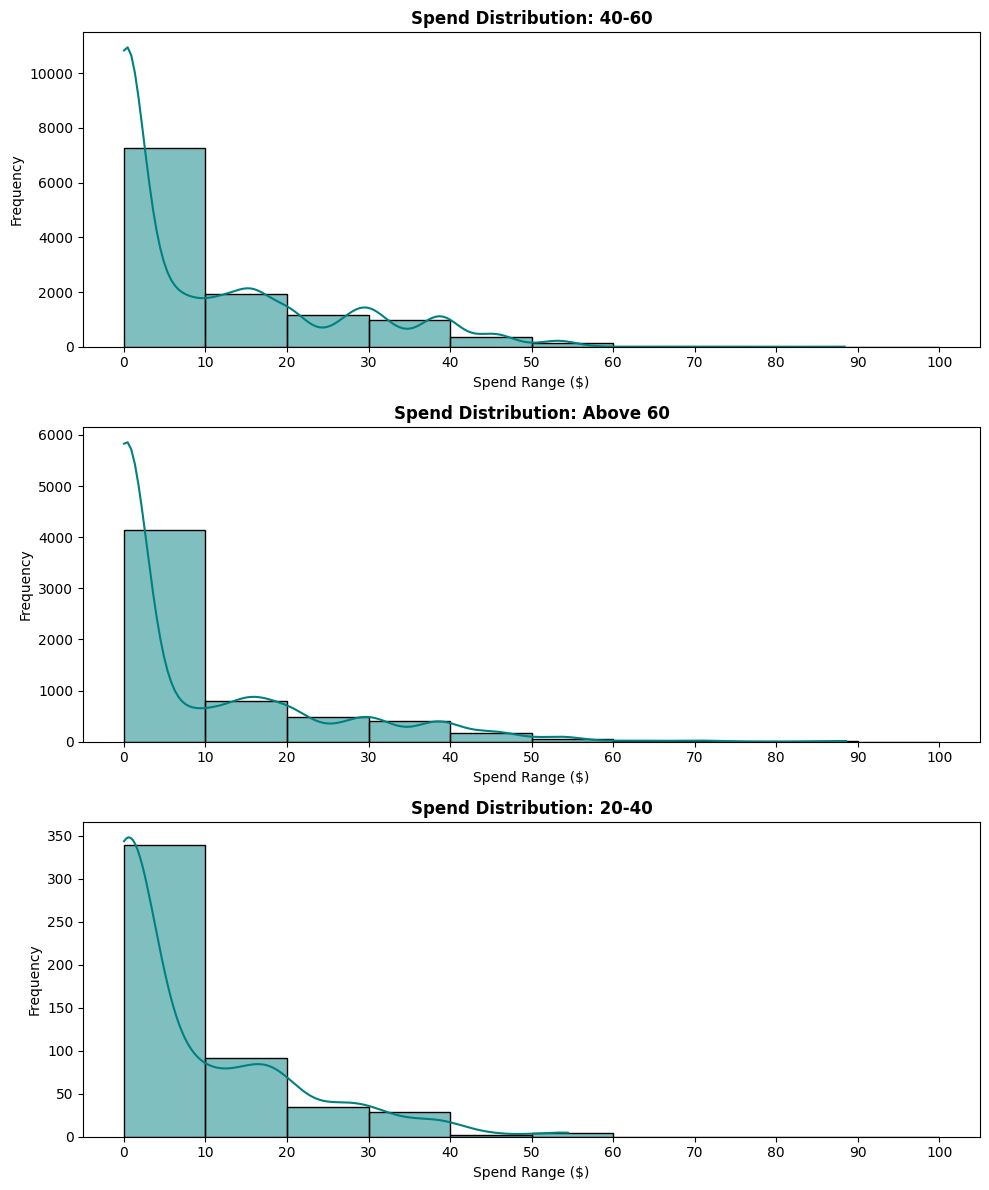

In [12]:
# There is a need to understand the distribution of the average monthly spend to discern better 
age_cats = df["age_category"].dropna().unique()
# create a figure with 3 ows 

# 1. Define your custom ranges (e.g., 0 to 100 in steps of 20)
custom_bins = [0,10, 20, 30, 40, 50, 60, 70, 80, 90, 100] 

fig, ax = plt.subplots(nrows=len(age_cats), ncols=1, figsize=(10, 12))

for i, age_cat in enumerate(age_cats):
    subset = df[df["age_category"] == age_cat]["average_monthly_spend"]
    
    # 2. Use 'bins=custom_bins' instead of a single number
    sns.histplot(subset, kde=True, ax=ax[i], color="teal", bins=custom_bins)
    
    # 3. Force the X-axis to show EXACTLY these labels
    ax[i].set_xticks(custom_bins)
    
    # 4. Optional: Rotate or format labels if they are crowded
    ax[i].set_xticklabels([f"{x}" for x in custom_bins])
    
    ax[i].set_title(f"Spend Distribution: {age_cat}", fontsize=12, fontweight='bold')
    ax[i].set_xlabel("Spend Range ($)")
    ax[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

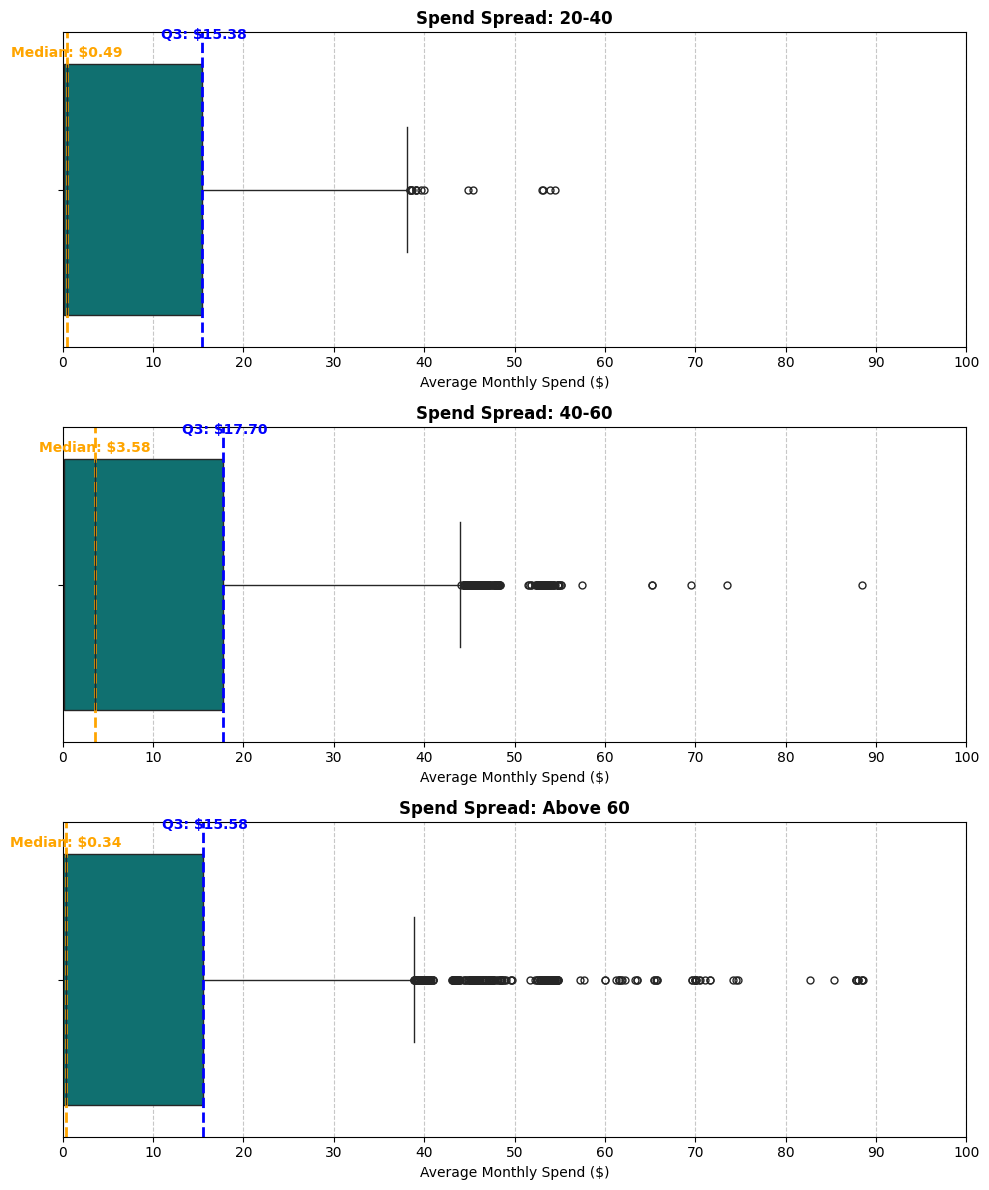

In [13]:

# Ensure age_cats is defined and cleaned
age_cats = df["age_category"].dropna().sort_values(ascending=True).unique()

# 1. Defining the range for the X-axis
custom_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100] 

# 2. Creating the subplots
fig, ax = plt.subplots(nrows=len(age_cats), ncols=1, figsize=(10, 4 * len(age_cats)))

for i, age_cat in enumerate(age_cats):
    # Filter the subset
    subset = df[df["age_category"] == age_cat]
    
    # Specify the column name to get a single numeric value for the median
    median_val = subset["average_monthly_spend"].median()
    q3_val = subset["average_monthly_spend"].quantile(0.75)
    
    # Boxplot
    sns.boxplot(data=subset, x="average_monthly_spend", ax=ax[i], color="teal", fliersize=5)

    # 4. Add the dotted line (axvline)
    ax[i].axvline(x=median_val, color='orange', linestyle='--', linewidth=2)
    ax[i].axvline(x=q3_val, color='blue', linestyle='--', linewidth=2)

    # Specify text ABOVE the line
    
    ax[i].text(x=median_val, y=-0.42, s=f'Median: ${median_val:.2f}', 
               color='orange', fontweight='bold', ha='center', fontsize=10)
    ax[i].text(x=q3_val + 0.2, y=-0.48, s=f'Q3: ${q3_val:.2f}', 
               color='blue', fontweight='bold', ha='center', fontsize=10)
    # 6. Set the X-axis limits and ticks
    ax[i].set_xlim(0, 100)
    ax[i].set_xticks(custom_bins)
    
    # Formatting
    ax[i].set_title(f"Spend Spread: {age_cat}", fontsize=12, fontweight='bold')
    ax[i].set_xlabel("Average Monthly Spend ($)")
    ax[i].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

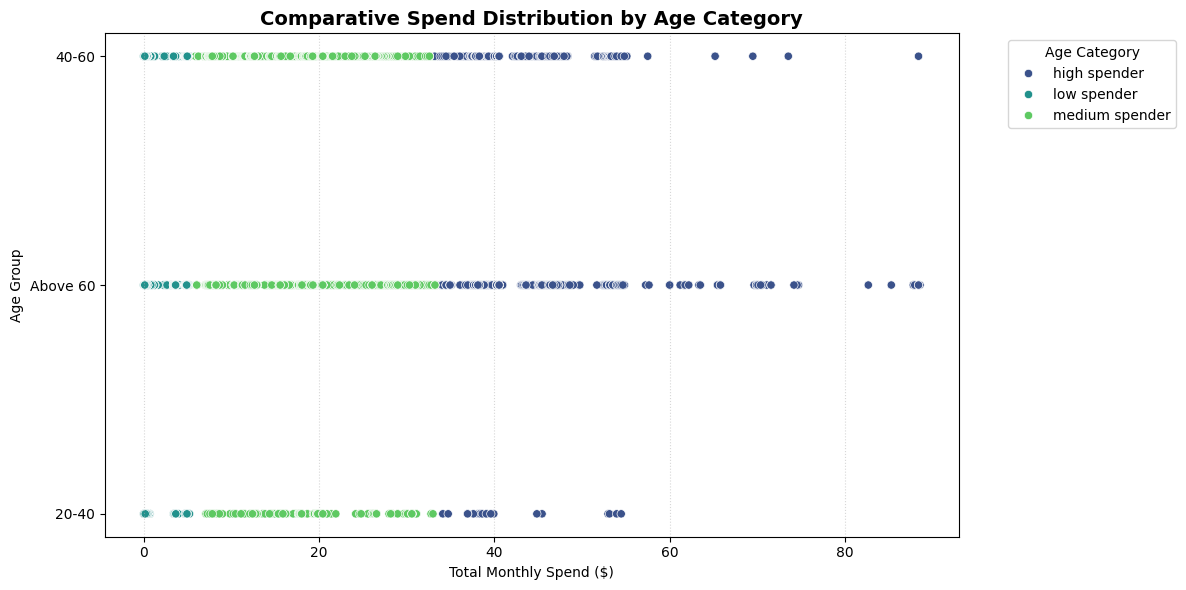

In [14]:


# create the figure
fig, ax = plt.subplots(figsize=(12, 6))

# create the scatter plot
#  'age_category' is used as the Y-axis to separate them into rows
# 'hue' automatically gives each category a unique color
sns.scatterplot(
    data=df, 
    x="average_monthly_spend", 
    y="age_category", 
    hue="spender_category", 
    palette="viridis", 
    ax=ax
)

ax.set_title("Comparative Spend Distribution by Age Category", fontsize=14, fontweight='bold')
ax.set_xlabel("Total Monthly Spend ($)")
ax.set_ylabel("Age Group")
ax.grid(axis='x', linestyle=':', alpha=0.5)
ax.legend(title="Age Category", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

<p> 4. Are customers with a high total_product count also those with the highest total_sales?

Insight: Determines if your revenue comes from high-volume "bulk" buyers or high-value "luxury" buyers. </p>

Text(0.5, 1.0, 'Volume (Products) vs. Value (Sales)')

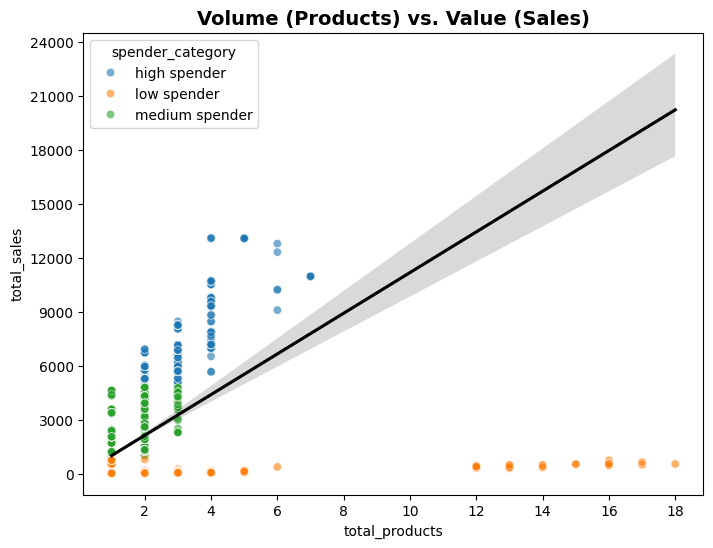

In [15]:
from matplotlib.ticker import MaxNLocator
fig4, ax4 = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x="total_products", y="total_sales", hue="spender_category", alpha=0.6, ax=ax4)
sns.regplot(data=df, x="total_products", y="total_sales", scatter=False, color="black", ax=ax4)

# Apply the integer locator to the X and Y axes to make the xticks integers
ax4.xaxis.set_major_locator(MaxNLocator(integer=True))
ax4.yaxis.set_major_locator(MaxNLocator(integer=True))

ax4.set_title("Volume (Products) vs. Value (Sales)", fontsize=14, fontweight='bold')

<h4> Insight 4 </h4>
<p> The highest amount of sales come from the high spenders and high luxury buyers</p>

<h4> Question 5</h4>
<p> 5.Which spender_category has the highest total_quantities per order? </p>

<em> Insight: Identifies potential wholesale or "power users" who move the most inventory </em>.

C:\Users\Mustapha\AppData\Local\Temp\ipykernel_16364\1267990661.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=q5_data.index, y=q5_data.values, palette="rocket", ax=ax5)


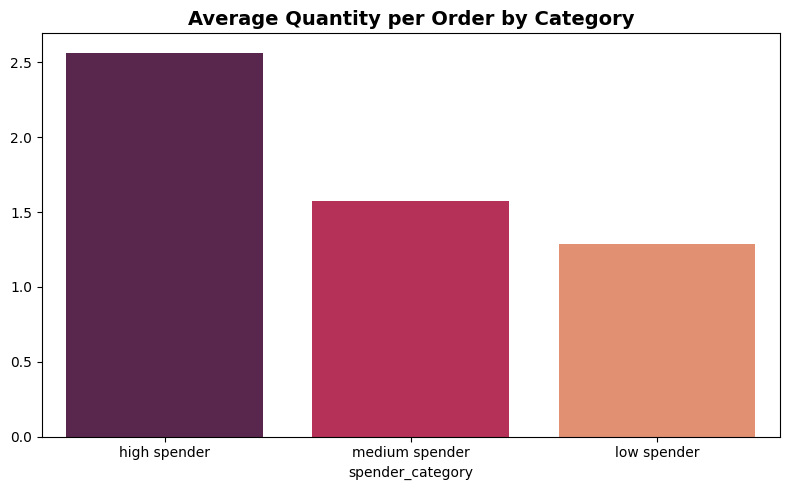

In [16]:
q5_data = df.groupby("spender_category")["total_quantities"].mean().sort_values(ascending=False)
fig5, ax5 = plt.subplots(figsize=(8, 5))
sns.barplot(x=q5_data.index, y=q5_data.values, palette="rocket", ax=ax5)
ax5.set_title("Average Quantity per Order by Category", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

<h4>Insight 5</h4>
<p> The high spenders have the highest average quantity per order</p>

<h3> B. Retention & Churn Risk Insights </h3>
<p> What is the average recency for each spender_category?

Insight: Highlights if your "High Spenders" are currently active or if they are "at-risk" of leaving (high recency).

Is there a correlation between life_span and total_sales?

Insight: Proves the "Loyalty Value"—showing exactly how much more a customer is worth the longer they stay.

Who are the "at-risk" champions (High total_sales but recency > 160 days)?

Insight: Creates a "Win-Back" list of formerly high-value customers who have stopped engaging.

What is the average life_span of a "Low Spender" vs. a "High Spender"?

Insight: Determines if low-value customers churn faster than high-value ones.
</p>

<h3> Question 6 </h3>
<p> What is the average recency for each spender_category?

Insight: Highlights if your "High Spenders" are currently active or if they are "at-risk" of leaving (high recency). </p>

In [17]:
df["recency"]
df.groupby("spender_category")["recency"].mean()

spender_category
high spender      151.299115
low spender       151.266396
medium spender    152.897617
Name: recency, dtype: float64

<h3>Insight 6</h3>
<p> The recency can be gotten accurately from this dataset </p>

<h3> Question 7 </h3>
<p>
Is there a correlation between life_span and total_sales?

Insight: Proves the "Loyalty Value"—showing exactly how much more a customer is worth the longer they stay. </p>


Text(0.5, 0, 'life_span')

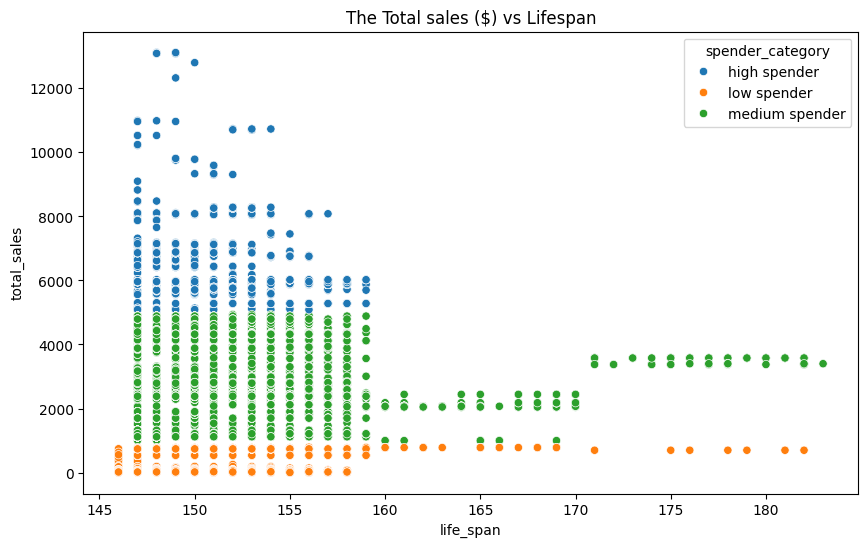

In [18]:
fig, ax = plt.subplots(figsize = (10,6))
plt.title("The Total sales ($) vs Lifespan")
sns.scatterplot(x= df["life_span"], y=df["total_sales"], hue=df["spender_category"], ax=ax)
plt.ylabel("total_sales")
plt.xlabel("life_span")

<h3> Insight 7 </h3>
<p> The high spenders have the lowest life span compared to other categories </p>

<h3> Question 8 </h3>
<p> 
Who are the "at-risk" champions (High total_sales but recency > 160 days)?

Insight: Creates a "Win-Back" list of formerly high-value customers who have stopped engaging. </p>

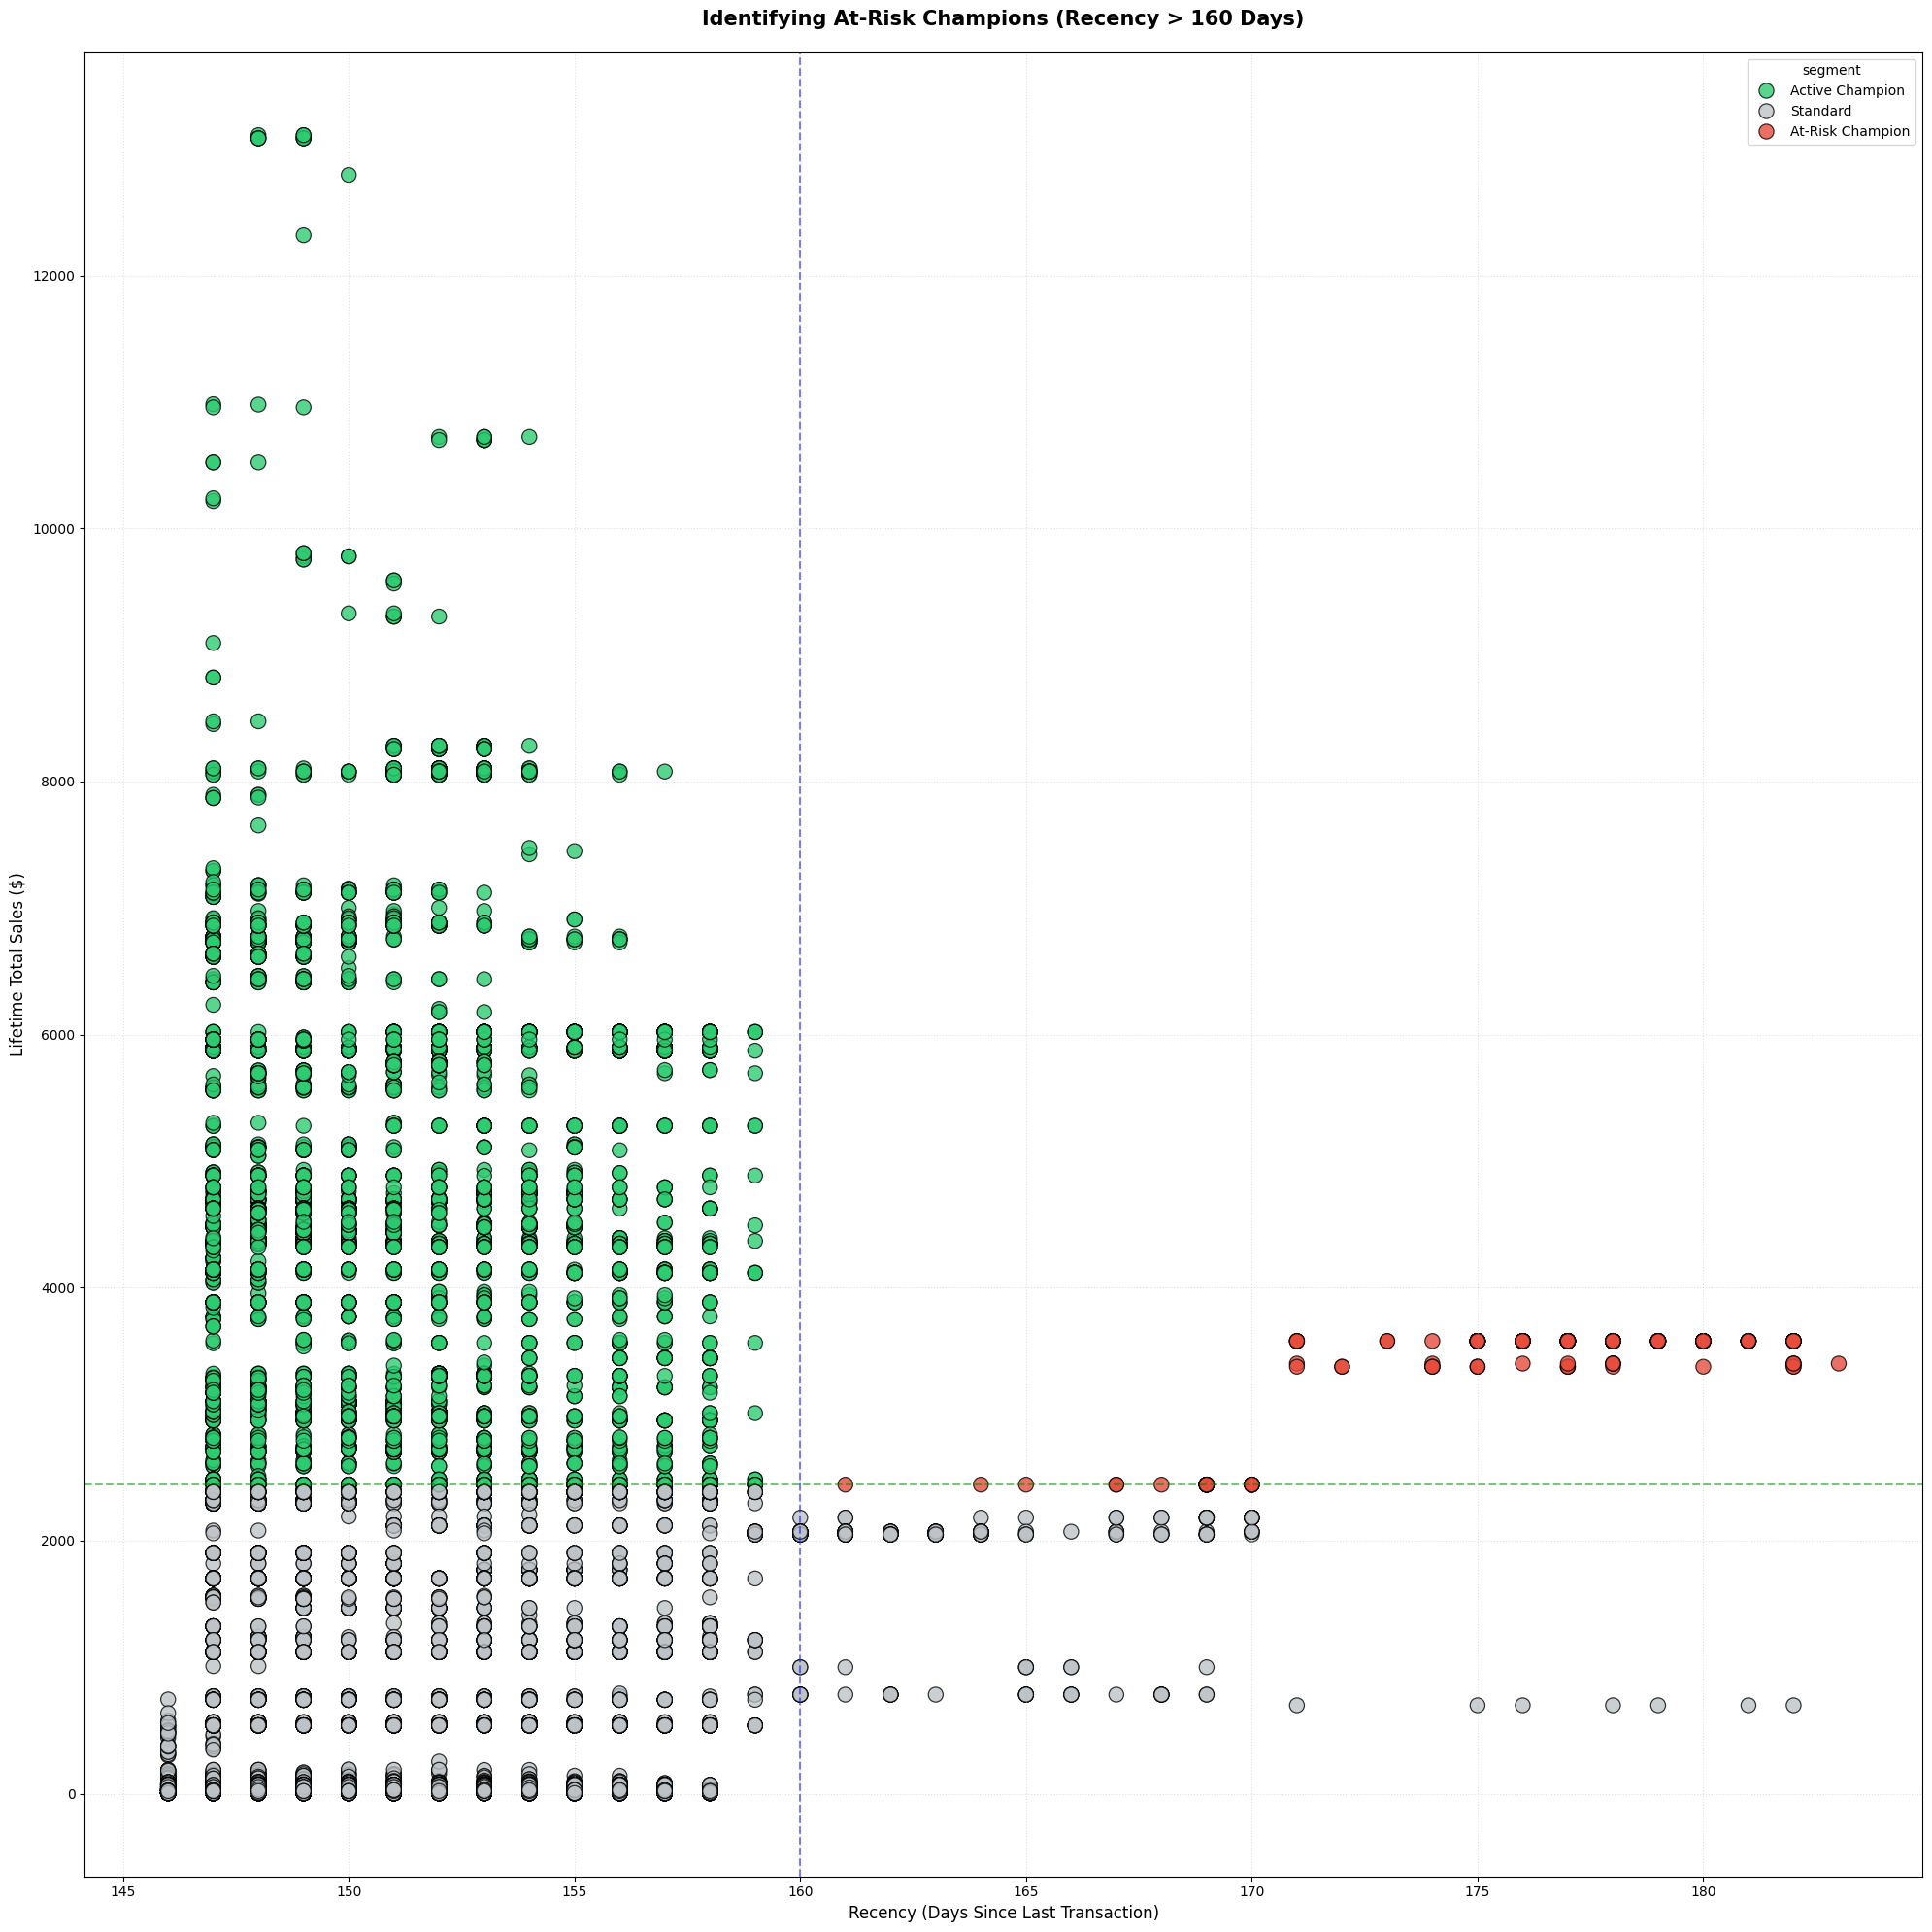

In [19]:
# Define the "At-Risk Champion" Logic
# Thresholds: Recency > 160 AND Sales in the top 25% (High Value)
recency_cutoff = 160
sales_cutoff = df['total_sales'].quantile(0.75)

def segment_customer(row):
    if row['recency'] > recency_cutoff and row['total_sales'] >= sales_cutoff:
        return 'At-Risk Champion'
    elif row['recency'] <= recency_cutoff and row['total_sales'] >= sales_cutoff:
        return 'Active Champion'
    else:
        return 'Standard'

df['segment'] = df.apply(segment_customer, axis=1)

# 3. Create the Visualization
fig, ax = plt.subplots(figsize=(20, 20))

# palette for labelling the different categories
palette = {
    'Active Champion': '#2ecc71',   # Green
    'At-Risk Champion': '#e74c3c',  # Red
    'Standard': '#bdc3c7'           # Gray
}

sns.scatterplot(
    data=df, x="recency", y="total_sales", 
    hue="segment", palette=palette, 
    s=120, alpha=0.8, edgecolor='black'
)

# 4. Add the "Danger Zone" Visual Markers
ax.axvline(x=recency_cutoff, color='blue', linestyle='--', alpha=0.5)
ax.axhline(y=sales_cutoff, color='green', linestyle='--', alpha=0.5)

# Formatting Ticks and Labels
ax.set_title("Identifying At-Risk Champions (Recency > 160 Days)", fontsize=15, fontweight='bold', pad=20)
ax.set_xlabel("Recency (Days Since Last Transaction)", fontsize=12)
ax.set_ylabel("Lifetime Total Sales ($)", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

In [20]:
df["segment"].value_counts()

segment
Standard            13705
Active Champion      4492
At-Risk Champion      282
Name: count, dtype: int64

<h3> Insight 8</h3>
<p> There are 282 at risk champions who are high transacting partners but have not made transactions in over 160 days and 4492 active champions who are high transacting partners but are still transacting</p>

<h3> C. Demographic & Segmentation Insights </h3>
<p>

What is the average age within each spender_category?

Insight: Helps build a "Buyer Persona" (e.g., "Our High Spenders are typically 35-45 years old").

Is the "Senior" age_category more likely to be a "Low" or "High" spender_category?

Insight: Refines your product offerings to match the financial capacity of specific age groups.
 </p>



<h3> Insight 9 </h3>
<p>
What is the average age within each spender_category?

Insight: Helps build a "Buyer Persona" (e.g., "Our High Spenders are typically 35-45 years old").

Is the "Senior" age_category more likely to be a "Low" or "High" spender_category?

Insight: Refines your product offerings to match the financial capacity of specific age groups. </p>

In [21]:
df.groupby("spender_category")["age_category"].count()

spender_category
high spender       1689
low spender       10820
medium spender     5954
Name: age_category, dtype: int64

In [22]:
df.groupby(["spender_category", "age_category"]).size()

spender_category  age_category
high spender      20-40             22
                  40-60           1143
                  Above 60         524
low spender       20-40            306
                  40-60           6592
                  Above 60        3922
medium spender    20-40            172
                  40-60           4117
                  Above 60        1665
dtype: int64

In [23]:
df.groupby(["spender_category", "age_category"]).size().reset_index(name='customer_count')

,spender_category,age_category,customer_count
0,high spender,20-40,22
1,high spender,40-60,1143
2,high spender,Above 60,524
3,low spender,20-40,306
4,low spender,40-60,6592
5,low spender,Above 60,3922
6,medium spender,20-40,172
7,medium spender,40-60,4117
8,medium spender,Above 60,1665


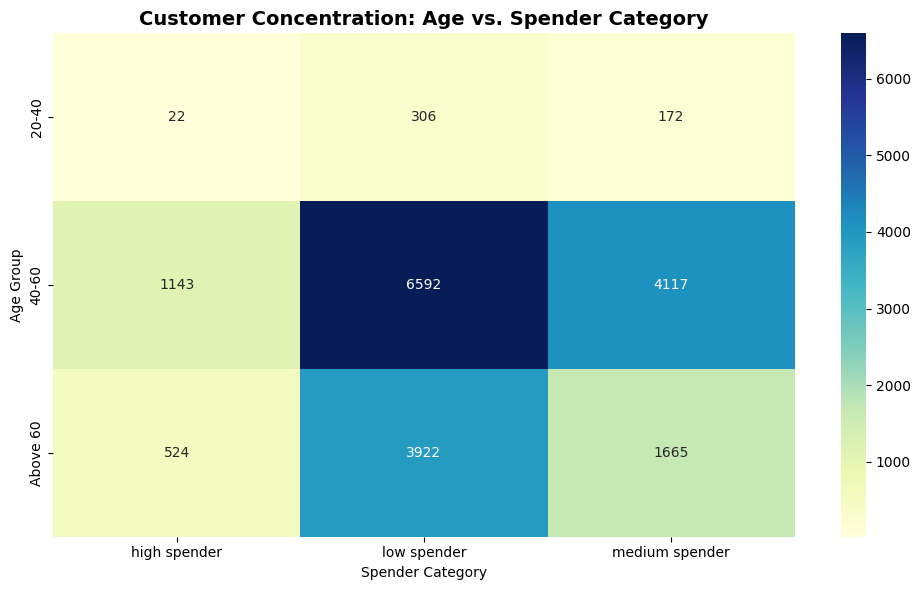

In [24]:

# This counts how many customers fall into each combination of categories
heatmap_data = pd.crosstab(df["age_category"], df["spender_category"])

# 2. Plotting the Heatmap
plt.figure(figsize=(10, 6))

# 'annot=True' puts the numbers inside the squares
# 'fmt="d"' ensures the numbers are whole integers
# 'cmap="YlGnBu"' is a color palette (Yellow to Green to Blue)
sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu")

# Formatting
plt.title("Customer Concentration: Age vs. Spender Category", fontsize=14, fontweight='bold')
plt.xlabel("Spender Category")
plt.ylabel("Age Group")

plt.tight_layout()
plt.show()

<h3> D. Behavioral & Operational Insights </h3>
<p>
How does last_order_date trend over time (Month-over-Month)?

Insight: Identifies seasonal peaks or a decline in overall business activity.

Which spender_category buys the most diverse range of total_products?

Insight: Shows cross-selling success. High diversity means customers are exploring your whole catalog.

Does a high life_span result in a higher average_monthly_spend?

Insight: Determines if customers become "more profitable" the longer they stay.

What percentage of revenue is contributed by the top 10% of customers (by customer_key)?

Insight: Measures "Customer Concentration Risk"—how much you rely on a tiny group of VIPs.

What is the "Revenue Velocity" (total_sales divided by life_span)?

Insight: Calculates the "Daily Value" of a customer, helping you set a maximum "Cost Per Acquisition" (CPA). </p>

<h3>Question 10</h3>
<p> How does last_order_date trend over time (Month-over-Month)?

Insight: Identifies seasonal peaks or a decline in overall business activity. </p>

In [25]:
df.head()

,customer_key,customer_number,customer_name,age,age_category,total_orders,total_sales,spender_category,last_order_date,recency,total_quantities,total_products,life_span,average_order_value,average_monthly_spend,segment
0,1,AW00011001,Eugene Huang,49.0,40-60,3,6235,high spender,2013-12-10,147,3,3,147,2078.3333,42.4150,Active Champion
1,2,AW00011002,Ruben Torres,55.0,40-60,3,8079,high spender,2013-02-23,157,3,3,157,2693.0000,51.4586,Active Champion
2,3,AW00011003,Christy Zhu,52.0,40-60,3,8079,high spender,2013-05-10,154,3,3,154,2693.0000,52.4610,Active Champion
3,4,AW00011004,Elizabeth Johnson,46.0,40-60,3,8104,high spender,2013-05-01,154,3,3,154,2701.3333,52.6234,Active Champion
4,5,AW00011005,Julio Ruiz,49.0,40-60,3,8079,high spender,2013-05-02,154,3,3,154,2693.0000,52.4610,Active Champion


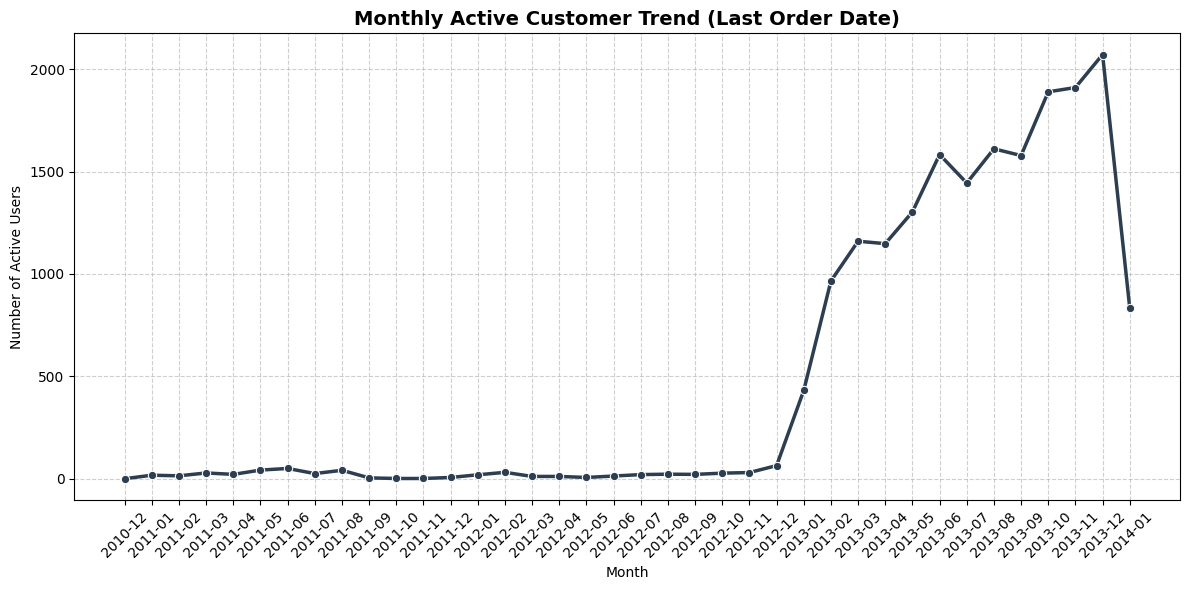

In [26]:

# Convert the data to pandas datetime format
df['last_order_date'] = pd.to_datetime(df['last_order_date'])

# Extract Year-Month for grouping
df['order_month'] = df['last_order_date'].dt.to_period('M').astype(str)

# Group by the order month
monthly_trend = df.groupby('order_month').size().reset_index(name='active_customers')

# 4. Plot the Trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_trend, x='order_month', y='active_customers', marker='o', color='#2c3e50', linewidth=2.5)

# Formatting
plt.title("Monthly Active Customer Trend (Last Order Date)", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Number of Active Users")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

<h3> Question 11 </h3>
<p> Which spender_category buys the most diverse range of total_products?

Insight: Shows cross-selling success. High diversity means customers are exploring your whole catalog. </p>

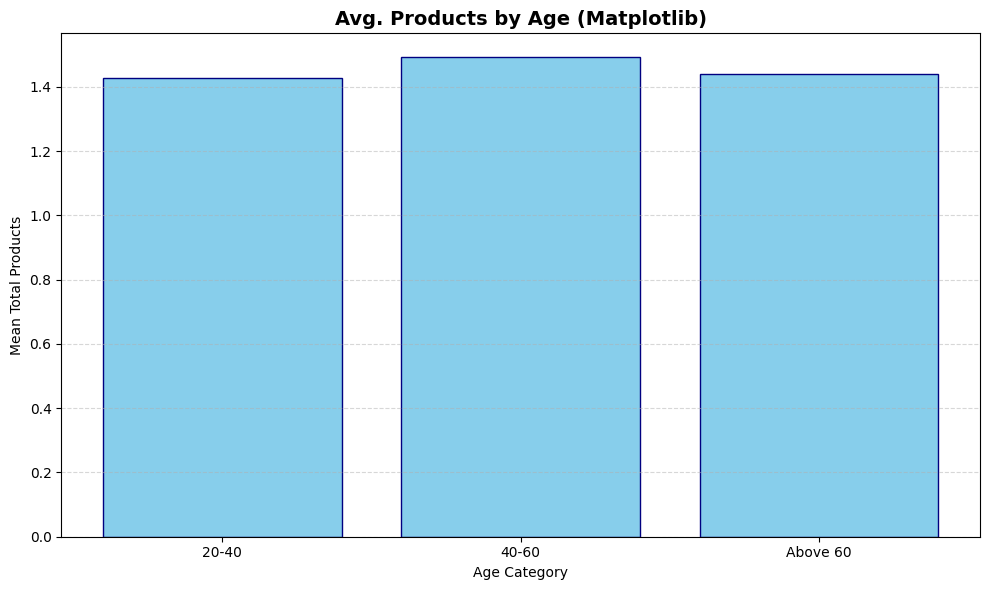

In [27]:
fig, ax = plt.subplots(figsize = (10,6))

spender_product_mean = df.groupby("age_category")["total_products"].mean()
ax.bar(x=spender_product_mean.index, height=spender_product_mean.values, color='skyblue', edgecolor='navy')
ax.set_title("Avg. Products by Age (Matplotlib)", fontsize=14, fontweight='bold')
ax.set_xlabel("Age Category")
ax.set_ylabel("Mean Total Products")
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<h3>Insight 11</h3>
<p> The 40-60 age category buy the most variety of products although the difference is not much for the other products</p>

In [28]:
df["total_products"]

0        3
1        3
2        3
3        3
4        3
        ..
18474    1
18475    1
18476    1
18477    1
18478    1
Name: total_products, Length: 18479, dtype: int64

<h3>Question 12 </h3>
<p> Does a high life_span result in a higher average_monthly_spend?

Insight: Determines if customers become "more profitable" the longer they stay.</p>

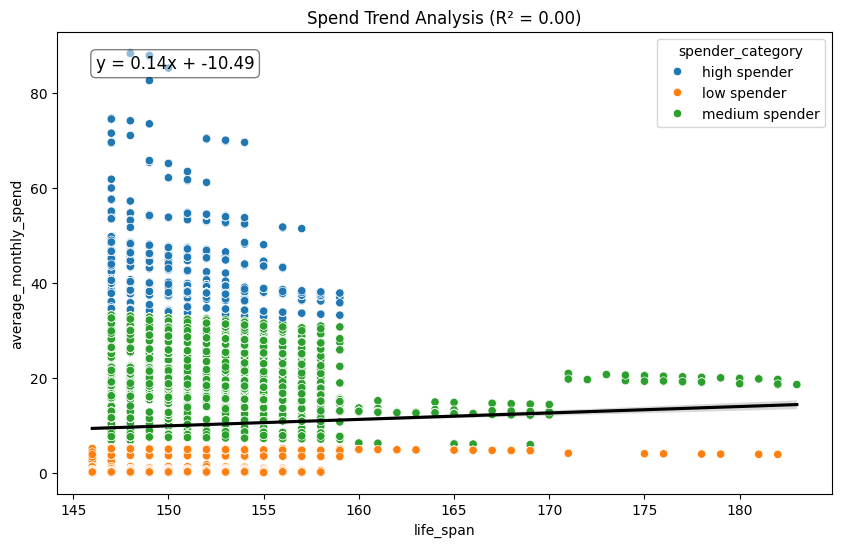

In [30]:
from scipy import stats

fig, ax = plt.subplots(figsize=(10, 6))

# plot the scatter plot of average monthly spend against life span
sns.scatterplot(data=df, x="life_span", y="average_monthly_spend", hue="spender_category", ax=ax)

# plot the regression line
sns.regplot(data=df, x="life_span", y="average_monthly_spend", scatter=False, color="black", ax=ax)

# Get the regression line parameters
slope, intercept, r_value, p_value, std_err = stats.linregress(df["life_span"], df["average_monthly_spend"])

# Format the Equation String
line_eq = f"y = {slope:.2f}x + {intercept:.2f}"

# Display the equation on the line plot
ax.text(0.05, 0.95, line_eq, transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

ax.set_title(f"Spend Trend Analysis (R² = {r_value**2:.2f})")
plt.show()

# set the title
ax.set_title("Life Span vs. Spend Trend")
plt.show()

<h3>Insight 12 </h3>
<p> The chart reveals that high spending customers after 160 days either churn or spend less with the customers between 145-165 days driving peak activity </p>



<h3> Question 13 </h3>
<p> What percentage of revenue is contributed by the top 10% of customers (by customer_key)?

Insight: Measures "Customer Concentration Risk"—how much you rely on a tiny group of VIPs. </p>

In [ ]:
top_10_revenue = df["total"]

In [41]:
top_10_cutoff = df["total_sales"].quantile(0.9)
top_10_cutoff

top_10_customers = df["total_sales"] > top_10_cutoff
top_10_customers = df[top_10_customers]
top_10_customers
top_10_revenue  = top_10_customers["total_sales"].sum()
total_revenue = df["total_sales"].sum()


top_10_revenue_percent = top_10_revenue/total_revenue*100
print(f"The top 10 percentile is {top_10_cutoff:.2f}")
print(f"The total revenue is ${total_revenue:.2f}")
print(f"The total revenue from customers in the top 10 percentile is ${top_10_revenue:.2f}")

print(f"The revenue of customers in top 10 percentile are {top_10_revenue_percent:.2f}% of the total revenue")


The top 10 percentile is 4763.00
The total revenue is $28429761.00
The total revenue from customers in the top 10 percentile is $11531461.00
The revenue of customers in top 10 percentile are 40.56% of the total revenue


<h3>Question 14</h3>
<p> What is the "Revenue Velocity" (total_sales divided by life_span)?

Insight: Calculates the "Daily Value" of a customer, helping you set a maximum "Cost Per Acquisition" (CPA). </p>

C:\Users\Mustapha\AppData\Local\Temp\ipykernel_16364\354443470.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=velocity_summary, x='spender_category', y='revenue_velocity', palette='viridis', ax=ax)


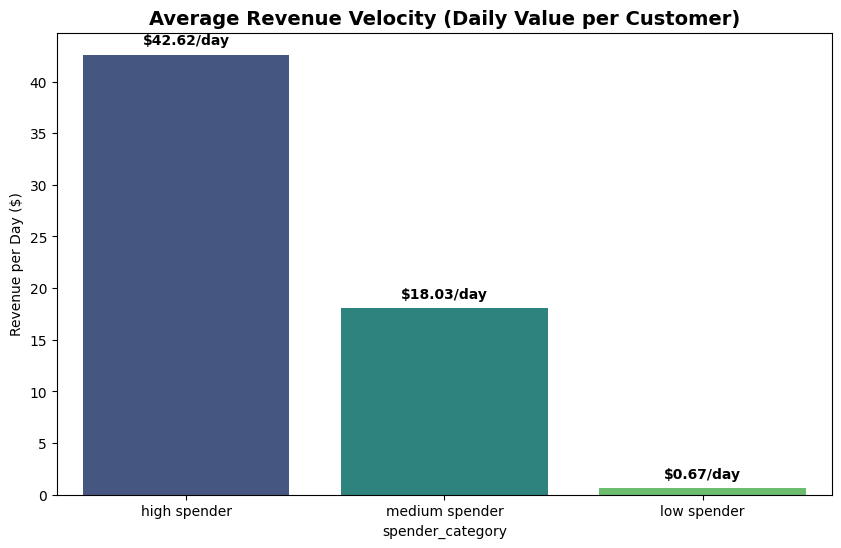

In [ ]:

# We divide the total money spent by the customer's lifespan (in days)
df['revenue_velocity'] = df['total_sales'] / df['life_span']

# Finding the average velocity for each category
velocity_summary = df.groupby('spender_category')['revenue_velocity'].mean().sort_values(ascending=False).reset_index()

# start the plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=velocity_summary, x='spender_category', y='revenue_velocity', palette='viridis', ax=ax)

# Add numeric value labels on top of bars
for p in ax.patches:
    ax.annotate(f'${p.get_height():.2f}/day', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontweight='bold')

ax.set_title("Average Revenue Velocity (Daily Value per Customer)", fontsize=14, fontweight='bold')
ax.set_ylabel("Revenue per Day ($)")
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18479 entries, 0 to 18478
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   customer_key           18479 non-null  int64         
 1   customer_number        18479 non-null  object        
 2   customer_name          18479 non-null  object        
 3   age                    18463 non-null  float64       
 4   age_category           18463 non-null  object        
 5   total_orders           18479 non-null  int64         
 6   total_sales            18479 non-null  int64         
 7   spender_category       18479 non-null  object        
 8   last_order_date        18479 non-null  datetime64[ns]
 9   recency                18479 non-null  int64         
 10  total_quantities       18479 non-null  int64         
 11  total_products         18479 non-null  int64         
 12  life_span              18479 non-null  int64         
 13  a